# First FM Acquisition per Sensor in the 97-99 MHz ROI

This notebook loads the acquisitions available in each `data/acquisitions/Node*.csv` file, extracts the `97-99 MHz` region of interest (ROI), and renders a **single plot** with the first ROI-intersecting acquisition from each sensor.

The CSV files do not all keep a single global band per sensor, so the notebook filters acquisitions at the per-row level and selects the first trace that actually intersects the requested ROI for every sensor.


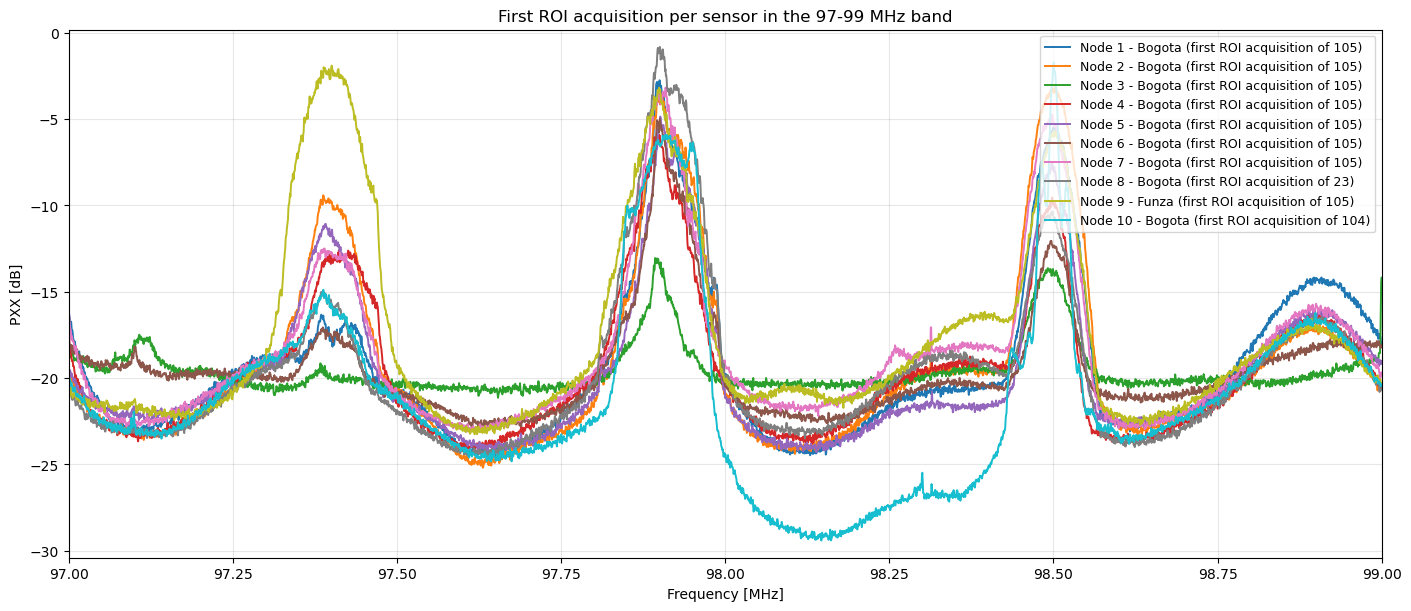

In [1]:
from __future__ import annotations

import csv
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

csv.field_size_limit(10**9)

ROI_START_MHZ = 97.0
ROI_END_MHZ = 99.0


@dataclass(frozen=True)
class SensorRoiAcquisitionSeries:
    """All ROI-intersecting acquisitions loaded from one sensor CSV file.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier extracted from the filename.
    location:
        Location label encoded in the filename.
    roi_frequency_hz:
        Shared frequency axis for the kept ROI samples [Hz].
    roi_traces_db:
        ROI traces with shape `(num_plotted_acquisitions, num_roi_bins)` in dB.
    total_acquisitions:
        Number of acquisitions available in the CSV file.
    plotted_acquisitions:
        Number of acquisitions whose band intersects the requested ROI.
    available_bands_mhz:
        Sorted list of unique acquisition bands observed in the file [MHz].
    """

    sensor_index: int
    location: str
    roi_frequency_hz: np.ndarray
    roi_traces_db: np.ndarray
    total_acquisitions: int
    plotted_acquisitions: int
    available_bands_mhz: tuple[tuple[float, float], ...]


def find_repository_root(start_dir: Path) -> Path:
    """Return the repository root by locating the acquisitions directory.

    Parameters
    ----------
    start_dir:
        Directory from which the upward search begins.

    Returns
    -------
    Path
        Repository root that contains `data/acquisitions`.

    Raises
    ------
    FileNotFoundError
        If the notebook is executed outside this repository tree.
    """

    for candidate in (start_dir, *start_dir.parents):
        if (candidate / "data" / "acquisitions").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing data/acquisitions."
    )


def extract_sensor_index(csv_path: Path) -> int:
    """Extract the numeric sensor index from a file named like `Node10-Bogota.csv`."""

    match = re.match(r"Node(\d+)-", csv_path.stem)
    if match is None:
        raise ValueError(f"Unexpected sensor filename: {csv_path.name}")

    return int(match.group(1))


def build_frequency_axis_hz(
    start_freq_hz: float,
    end_freq_hz: float,
    num_points: int,
) -> np.ndarray:
    """Build the uniform frequency axis for one acquisition.

    The spectrum bins are assumed to cover the half-open interval
    `[start_freq_hz, end_freq_hz)` with constant spacing.

    Parameters
    ----------
    start_freq_hz:
        Lower edge of the measured frequency range [Hz].
    end_freq_hz:
        Upper edge of the measured frequency range [Hz].
    num_points:
        Number of spectral samples stored in each `pxx` trace.

    Returns
    -------
    np.ndarray
        Frequency axis with one value per spectral sample.

    Raises
    ------
    ValueError
        If the provided range or sample count is invalid.
    """

    if num_points <= 0:
        raise ValueError("num_points must be strictly positive.")

    if not np.isfinite(start_freq_hz) or not np.isfinite(end_freq_hz):
        raise ValueError("Frequency bounds must be finite numeric values.")

    if end_freq_hz <= start_freq_hz:
        raise ValueError("end_freq_hz must be strictly larger than start_freq_hz.")

    return np.linspace(start_freq_hz, end_freq_hz, num_points, endpoint=False)


def parse_pxx_trace(pxx_literal: str, csv_name: str) -> np.ndarray:
    """Parse one serialized `pxx` field into a validated 1D float32 array.

    Parameters
    ----------
    pxx_literal:
        Serialized Python-style list stored in the CSV file.
    csv_name:
        CSV filename used to produce actionable validation errors.

    Returns
    -------
    np.ndarray
        One-dimensional spectral trace in dB.

    Raises
    ------
    ValueError
        If the trace cannot be parsed or contains invalid numeric values.
    """

    try:
        pxx_db = np.fromstring(pxx_literal.strip()[1:-1], sep=",", dtype=np.float32)
    except ValueError as exc:
        raise ValueError(f"Could not parse the pxx array from {csv_name}.") from exc

    if pxx_db.ndim != 1 or pxx_db.size == 0:
        raise ValueError(f"The pxx array in {csv_name} must be a non-empty 1D array.")

    if not np.isfinite(pxx_db).all():
        raise ValueError(f"The pxx array in {csv_name} contains NaN or Inf values.")

    return pxx_db


def load_roi_acquisitions(
    csv_path: Path,
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> SensorRoiAcquisitionSeries:
    """Load only the acquisitions that intersect the requested ROI.

    Parameters
    ----------
    csv_path:
        Path to a sensor acquisition CSV file.
    roi_start_mhz:
        Lower ROI limit for the x-axis [MHz].
    roi_end_mhz:
        Upper ROI limit for the x-axis [MHz].

    Returns
    -------
    SensorRoiAcquisitionSeries
        ROI-only traces for the requested sensor.

    Raises
    ------
    ValueError
        If the CSV is empty, if the ROI is invalid, or if the intersecting
        acquisitions do not share the same ROI grid.
    """

    if roi_end_mhz <= roi_start_mhz:
        raise ValueError("roi_end_mhz must be strictly larger than roi_start_mhz.")

    with csv_path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))

    if not rows:
        raise ValueError(f"The file {csv_path.name} does not contain acquisitions.")

    roi_start_hz = roi_start_mhz * 1e6
    roi_end_hz = roi_end_mhz * 1e6

    roi_frequency_hz: np.ndarray | None = None
    roi_traces_db: list[np.ndarray] = []
    available_bands_hz: set[tuple[float, float]] = set()

    # Extract the ROI per acquisition because some files mix acquisition bands.
    for row in rows:
        try:
            start_freq_hz = float(row["start_freq_hz"])
            end_freq_hz = float(row["end_freq_hz"])
        except (KeyError, TypeError, ValueError) as exc:
            raise ValueError(f"Malformed frequency metadata in {csv_path.name}.") from exc

        available_bands_hz.add((start_freq_hz, end_freq_hz))

        pxx_db = parse_pxx_trace(row["pxx"], csv_path.name)
        frequency_hz = build_frequency_axis_hz(
            start_freq_hz=start_freq_hz,
            end_freq_hz=end_freq_hz,
            num_points=pxx_db.size,
        )
        roi_mask = (frequency_hz >= roi_start_hz) & (frequency_hz <= roi_end_hz)

        if not np.any(roi_mask):
            continue

        candidate_roi_frequency_hz = frequency_hz[roi_mask]
        candidate_roi_trace_db = pxx_db[roi_mask]

        if roi_frequency_hz is None:
            roi_frequency_hz = candidate_roi_frequency_hz
        elif not np.allclose(roi_frequency_hz, candidate_roi_frequency_hz):
            raise ValueError(
                f"Inconsistent ROI grid detected across acquisitions in {csv_path.name}."
            )

        roi_traces_db.append(candidate_roi_trace_db)

    location_parts = csv_path.stem.split("-", maxsplit=1)
    if len(location_parts) != 2:
        raise ValueError(f"Could not extract the location from {csv_path.name}.")

    if roi_frequency_hz is None:
        roi_frequency_hz = np.empty(0, dtype=np.float64)

    if roi_traces_db:
        roi_traces_array = np.vstack(roi_traces_db)
    else:
        roi_traces_array = np.empty((0, roi_frequency_hz.size), dtype=np.float32)

    available_bands_mhz = tuple(
        sorted((start_hz / 1e6, end_hz / 1e6) for start_hz, end_hz in available_bands_hz)
    )

    return SensorRoiAcquisitionSeries(
        sensor_index=extract_sensor_index(csv_path),
        location=location_parts[1],
        roi_frequency_hz=roi_frequency_hz,
        roi_traces_db=roi_traces_array,
        total_acquisitions=len(rows),
        plotted_acquisitions=roi_traces_array.shape[0],
        available_bands_mhz=available_bands_mhz,
    )


def plot_first_roi_acquisition_per_sensor(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> None:
    """Plot the first ROI-intersecting acquisition from each sensor on one axis.

    Parameters
    ----------
    acquisition_series:
        Ordered list containing every sensor and its ROI traces.
    roi_start_mhz:
        Lower ROI limit for the x-axis [MHz].
    roi_end_mhz:
        Upper ROI limit for the x-axis [MHz].

    Returns
    -------
    None
        The function renders a matplotlib figure and does not mutate the inputs.

    Raises
    ------
    ValueError
        If the input list is empty, if the ROI is invalid, or if no sensor
        contributes at least one ROI-intersecting acquisition.
    """

    if not acquisition_series:
        raise ValueError("At least one sensor series is required to build the plot.")

    if roi_end_mhz <= roi_start_mhz:
        raise ValueError("roi_end_mhz must be strictly larger than roi_start_mhz.")

    figure, axis = plt.subplots(figsize=(14, 6), constrained_layout=True)

    plotted_traces: list[np.ndarray] = []
    skipped_sensors: list[str] = []

    # Plot only the first valid ROI acquisition per sensor so the notebook stays on one axis.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            skipped_sensors.append(f"Node {series.sensor_index} - {series.location}")
            continue

        roi_frequency_mhz = series.roi_frequency_hz / 1e6
        first_roi_trace_db = series.roi_traces_db[0]
        plotted_traces.append(first_roi_trace_db)
        axis.plot(
            roi_frequency_mhz,
            first_roi_trace_db,
            linewidth=1.4,
            label=(
                f"Node {series.sensor_index} - {series.location} "
                f"(first ROI acquisition of {series.total_acquisitions})"
            ),
        )

    if not plotted_traces:
        raise ValueError("No acquisition intersects the requested ROI.")

    global_roi_min = min(float(trace.min()) for trace in plotted_traces)
    global_roi_max = max(float(trace.max()) for trace in plotted_traces)

    axis.set_title(
        f"First ROI acquisition per sensor in the {roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz band"
    )
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PXX [dB]")
    axis.set_xlim(roi_start_mhz, roi_end_mhz)
    axis.set_ylim(global_roi_min - 1.0, global_roi_max + 1.0)
    axis.grid(True, alpha=0.3)
    axis.legend(loc="upper right", fontsize=9)

    # Surface skipped sensors explicitly instead of silently dropping them from the figure.
    if skipped_sensors:
        axis.text(
            0.02,
            0.02,
            "No ROI acquisition for: " + ", ".join(skipped_sensors),
            transform=axis.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"},
        )

    plt.show()


# Resolve the data directory relative to the repository root, not to a fragile cwd assumption.
repository_root = find_repository_root(Path.cwd())
data_dir = repository_root / "data" / "acquisitions"

# Load the ten sensor files in numeric order so line colors and legend entries stay stable.
sensor_paths = sorted(data_dir.glob("Node*.csv"), key=extract_sensor_index)
if len(sensor_paths) != 10:
    raise ValueError(f"Expected 10 sensor files in {data_dir}, found {len(sensor_paths)}.")

acquisition_series = [
    load_roi_acquisitions(
        csv_path=sensor_path,
        roi_start_mhz=ROI_START_MHZ,
        roi_end_mhz=ROI_END_MHZ,
    )
    for sensor_path in sensor_paths
]
plot_first_roi_acquisition_per_sensor(
    acquisition_series=acquisition_series,
    roi_start_mhz=ROI_START_MHZ,
    roi_end_mhz=ROI_END_MHZ,
)
